In [1]:
# Student name: Amir Gharghabi
# Course: ML
# HW5
# Q7

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from PIL import Image

In [9]:
imagePath = 'dataset/forest.jpg'

G:\UT\Term1\ML\Python\virtual_env_3_9\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
G:\UT\Term1\ML\Python\virtual_env_3_9\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
G:\UT\Term1\ML\Python\virtual_env_3_9\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
G:\UT\Term1\ML\Python\virtual_env_3_9\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The 

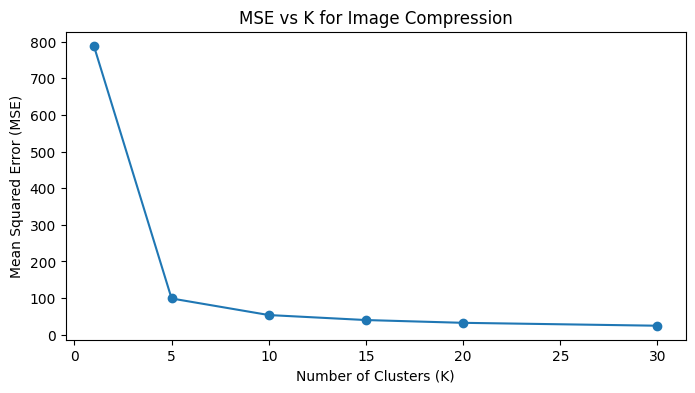

In [21]:
imagePath = 'dataset/forest.jpg'
img = Image.open(imagePath)
img = np.array(img)

pixels = img.reshape((-1, 3))

#K_values = [5]
K_values = [1, 5, 10, 15, 20, 30]

mse_values = []

img_flat = img.reshape(-1, 3)
compressed_img_5_colors = None
for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    compressed_pixels = centers[labels]
    compressed_img = compressed_pixels.reshape(img.shape)
    compressed_img_flat = compressed_img.reshape(-1, 3)
    mse = mean_squared_error(img_flat, compressed_img_flat)
    mse_values.append(mse)
    if k == 5:
        compressed_img_5_colors = compressed_img

# Plot the MSE values for different values of K
plt.figure(figsize=(8, 4))
plt.plot(K_values, mse_values, marker='o')
plt.title('MSE vs K for Image Compression')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Mean Squared Error (MSE)')
plt.show()


In [24]:
compressed_img_5_colors.shape

(488, 650, 3)

In [26]:
compressed_img_5_colors_int = compressed_img_5_colors.astype(int)

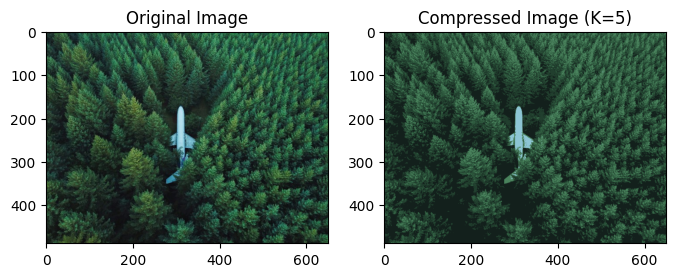

In [28]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.title('Compressed Image (K=5)')
plt.imshow(compressed_img_5_colors_int)
plt.show()